# Discrete convolution

$$
z[n] = (x * y)[n] = \sum_{k=-\infty}^{\infty} x[k]\,y[n-k]
$$



### Example
$$
x[n] = \{\textbf{1}, 2, 3, 4, 5\}\ ,\quad y[n] = \{-1, \textbf{2}, 1\}\qquad(\text{bold} \rightarrow n=0)
$$

$$
\renewcommand{\arraystretch}{1.3}
\begin{array}{cc|ccccc|cc|c}
0 & 0 & \mathbf{1} & 2 & 3 & 4 & 5 & 0 & 0 & z[n] \\ \hline
1 & 2 & -1 & 0 & 0 & 0 & 0 & 0 & 0 & -1 \\
0 & 1 & 2 & -1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 2 & -1 & 0 & 0 & 0 & 0 & 2 \\
0 & 0 & 0 & 1 & 2 & -1 & 0 & 0 & 0 & 4 \\
0 & 0 & 0 & 0 & 1 & 2 & -1 & 0 & 0 & 6 \\
0 & 0 & 0 & 0 & 0 & 1 & 2 & -1 & 0 & 14 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 2 & -1 & 5
\end{array}
$$

In matrix form:
$$
(x * y)
=
\begin{bmatrix}
-1 & 0 & 0 & 0 & 0 \\
2 & -1 & 0 & 0 & 0 \\
1 & 2 & -1 & 0 & 0 \\
0 & 1 & 2 & -1 & 0 \\
0 & 0 & 1 & 2 & -1 \\
0 & 0 & 0 & 1 & 2 \\
0 & 0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
1\\
2\\
3\\
4\\
5
\end{bmatrix}
 = 
\begin{bmatrix}
-1\\
0\\
2\\
4\\
6\\
14\\
5
\end{bmatrix}
$$

### How to code it:
$$
z[n]=(x*y)[n]=\sum_{k=-\infty}^{\infty}
\underbrace{x[k]}_{0\le k< N}\,
\underbrace{y[n-k]}_{0\le n-k< M}\qquad n\in\mathbb{Z}
$$

$$
\underbrace{0\le k< N}_{x[k]},
\qquad
\underbrace{0\le n-k< M}_{y[n-k]}\qquad (*)
$$

$$
0\le k< N,
\qquad
n- M< k\le n
$$

$$
\max\!\bigl(0,\;n-(M-1)\bigr)\le k\le \min(n,\;N-1)\qquad (**)
$$

$$
z[n]=
\sum_{k=\max(0,\;n-(M-1))}^{\min(n,\;N-1)}
x[k]\,y[n-k]\qquad 0 \le n < N + M\qquad (***)
$$

In [4]:
x = [1, 2, 3, 4, 5]
y = [-1, 2, 1]

# version 1: let's not worry about limits too early
for n in range(-10, 10): # explicit Python loop
    s = 0
    for k in range(-10, 10):# explicit Python loop
        if k >= len(x) or n - k >= len(y) or k < 0 or n-k < 0:   # according to conditions in (*)
            continue
        else:
            s += x[k]*y[n-k]
    print(s, end=",")


0,0,0,0,0,0,0,0,0,0,-1,0,2,4,6,14,5,0,0,0,

In [6]:
x = [1, 2, 3, 4, 5]
y = [-1, 2, 1]
    
# version 2: implementing (**) and (***)
for n in range(len(x) + len(y) - 1):# explicit Python loop
    s = 0
    for k in range(max(n - len(y)+1, 0), min(n+1, len(x))):# explicit Python loop
            s += x[k]*y[n-k]
    print(s, end=",")

-1,0,2,4,6,14,5,

In [10]:
# Using numeric Python
import numpy as np
x = np.array([1, 2, 3, 4, 5])
y = np.array([-1, 2, 1])
    


# version 3: one explicit loop + vectorized operation
for n in range(len(x) + len(y) - 1):# explicit Python loop
    k = np.arange(max(n - len(y)+1, 0), min(n+1, len(x))) # vectorized op.
    print((x[k]*y[n-k]).sum(), end=",") # vectorized op.

-1,0,2,4,6,14,5,

In [24]:
# Using numeric Python
import numpy as np
x = np.array([1, 2, 3, 4, 5])
y = np.array([-1, 2, 1])
 
# one liners with one explicit loop + vectorized op.

# version 4    
print([(x[np.arange(max(n - len(y)+1, 0), min(n+1, len(x)))]*y[n-np.arange(max(n - len(y)+1, 0), min(n+1, len(x)))]).sum() for n in range(len(x) + len(y) - 1)])

# version 5
print([(lambda k: x[k]*y[n-k])(np.arange(max(n - len(y)+1, 0), min(n+1, len(x)))).sum() for n in range(len(x) + len(y) - 1)])

[-1, 0, 2, 4, 6, 14, 5]
[-1, 0, 2, 4, 6, 14, 5]


In [30]:
# convolution using the matrix multiplication approach
# applying only vectorized operations
n, m = len(x), len(y)
i, j =np.arange(n+m-1), np.arange(n)
i,j

(array([0, 1, 2, 3, 4, 5, 6]), array([0, 1, 2, 3, 4]))

In [31]:
I, J = np.meshgrid(j, i)
I, J

(array([[0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4]]),
 array([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3],
        [4, 4, 4, 4, 4],
        [5, 5, 5, 5, 5],
        [6, 6, 6, 6, 6]]))

In [32]:
tmp = J-I
tmp

array([[ 0, -1, -2, -3, -4],
       [ 1,  0, -1, -2, -3],
       [ 2,  1,  0, -1, -2],
       [ 3,  2,  1,  0, -1],
       [ 4,  3,  2,  1,  0],
       [ 5,  4,  3,  2,  1],
       [ 6,  5,  4,  3,  2]])

In [33]:
tmp[tmp >= m] = -1
tmp

array([[ 0, -1, -2, -3, -4],
       [ 1,  0, -1, -2, -3],
       [ 2,  1,  0, -1, -2],
       [-1,  2,  1,  0, -1],
       [-1, -1,  2,  1,  0],
       [-1, -1, -1,  2,  1],
       [-1, -1, -1, -1,  2]])

In [34]:
ind = np.where(tmp >= 0)
ind

(array([0, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 6]),
 array([0, 0, 1, 0, 1, 2, 1, 2, 3, 2, 3, 4, 3, 4, 4]))

In [44]:
H = np.zeros([n + m -1, n], dtype=int) # without 'dtype' it will use float
H[ind]=y[tmp[ind]]
H

array([[-1,  0,  0,  0,  0],
       [ 2, -1,  0,  0,  0],
       [ 1,  2, -1,  0,  0],
       [ 0,  1,  2, -1,  0],
       [ 0,  0,  1,  2, -1],
       [ 0,  0,  0,  1,  2],
       [ 0,  0,  0,  0,  1]])

In [45]:
np.mat(H)*np.mat(x).T  # multiplying as matrices

matrix([[-1],
        [ 0],
        [ 2],
        [ 4],
        [ 6],
        [14],
        [ 5]])

In [46]:
np.array(np.mat(H)*np.mat(x).T).flatten() 

array([-1,  0,  2,  4,  6, 14,  5])

In [48]:
def convolve(x, y):
    """
    using version 3 : one explicit loop + vectorized operation
    """
    z = np.zeros(len(x) + len(y) - 1)
    for n in range(len(z)):# explicit Python loop
        k = np.arange(max(n - len(y)+1, 0), min(n+1, len(x))) # vectorized op.
        z[n] = (x[k]*y[n-k]).sum() # vectorized op.
    return z

In [49]:
convolve(x, y)

array([-1.,  0.,  2.,  4.,  6., 14.,  5.])

In [51]:
N = 10
impulse = np.zeros(N)
impulse[0] = 1
impulse

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [52]:
convolve(x, impulse)

array([1., 2., 3., 4., 5., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [53]:
convolve(impulse, x)

array([1., 2., 3., 4., 5., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [55]:
step = np.zeros(N)
step[:N//2] = 1
step

array([1., 1., 1., 1., 1., 0., 0., 0., 0., 0.])

In [56]:
convolve(step, step)

array([1., 2., 3., 4., 5., 4., 3., 2., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.])

<StemContainer object of 3 artists>

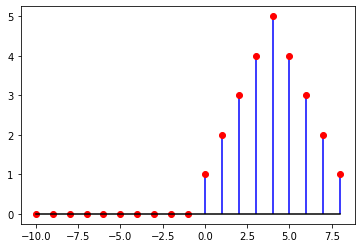

In [69]:
import matplotlib.pyplot as plt
n = np.arange(N) - N//2
nc = np.arange(2*N -1)-N
plt.stem(nc, convolve(step[n], step[n]), linefmt='b-', markerfmt='ro', basefmt='k-')